# 🚀 Module 02: Exploratory Data Analysis (EDA) & Data Visualization
**Course:** The Ultimate Machine Learning Roadmap
**Objective:** Learn to *listen* to your data before modeling — distributions, relationships, categories, and outliers.

---

## 📖 1. Why EDA Comes Before Modeling

In Module 01 we cleaned a dataset (missing values, encoding, scaling). But cleaning alone doesn't tell us **what's actually going on** in the data. Exploratory Data Analysis (EDA) is the detective work that happens between cleaning and modeling.

### 🎯 Goals of EDA
1. **Understand distributions** — is a feature skewed? normal? bimodal?
2. **Find relationships** — which features move together? which predict the target?
3. **Spot outliers** — points that could break your model or reveal data errors.
4. **Check categorical balance** — is one class overrepresented?
5. **Build intuition** — a good EDA often tells you which model family will work best, before you train anything.

> 💡 **Rule of thumb:** if you can't explain a pattern in a chart, don't trust a model built on top of it.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline
np.random.seed(42)

print("✅ Libraries imported successfully!")
#if any library you need activate env like this-->conda activate ML

✅ Libraries imported successfully!


## 🏗 2. Building Our Playground Dataset

We'll simulate an **Employee Dataset** — 200 employees with age, salary, years of experience, department, and whether they left the company (`Attrition`). This mirrors a real HR analytics problem.


In [2]:
n = 200

departments = np.random.choice(
    ['Engineering', 'Sales', 'HR', 'Marketing'],
    size=n, p=[0.4, 0.3, 0.15, 0.15]
)

experience = np.random.gamma(shape=2.0, scale=3.0, size=n).round(1)
age = (22 + experience + np.random.normal(0, 3, n)).round().astype(int)
age = np.clip(age, 21, 65)

base_salary = 35000 + experience * 4200 + np.random.normal(0, 4000, n)
dept_bonus = pd.Series(departments).map({'Engineering': 12000, 'Sales': 6000, 'HR': 0, 'Marketing': 3000}).values
salary = (base_salary + dept_bonus).round(-2)

# A handful of high-earner outliers (execs)
outlier_idx = np.random.choice(n, size=4, replace=False)
salary[outlier_idx] *= np.random.uniform(2.2, 3.0, size=4)

attrition_prob = 1 / (1 + np.exp(-(-2.5 + 0.15 * (10 - experience) + 0.00002 * (60000 - salary))))
attrition = (np.random.rand(n) < attrition_prob).astype(int)

df = pd.DataFrame({
    'Age': age,
    'Department': departments,
    'YearsExperience': experience,
    'Salary': salary,
    'Attrition': attrition
})

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200, 5)


,Age,Department,YearsExperience,Salary,Attrition
0,31,Engineering,2.8,51700.0,0
1,28,Marketing,6.0,66200.0,0
2,29,HR,6.2,55400.0,0
3,24,Sales,2.7,57300.0,1
4,38,Engineering,16.3,106800.0,0


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,200.0,NaN,NaN,NaN,28.205,5.237378,21.0,24.0,28.0,31.0,46.0
Department,200,4,Engineering,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YearsExperience,200.0,NaN,NaN,NaN,6.1765,4.297188,0.5,2.8,5.1,8.15,20.4
Salary,200.0,NaN,NaN,NaN,71104.945848,30690.058915,30500.0,53350.0,64850.0,79775.0,273548.809828
Attrition,200.0,NaN,NaN,NaN,0.15,0.357967,0.0,0.0,0.0,0.0,1.0


## 📊 3. Univariate Analysis: One Feature at a Time

Before comparing features, look at each one alone.
- **Histograms / KDE** reveal shape (skew, modality).
- **Boxplots** reveal spread and outliers at a glance.


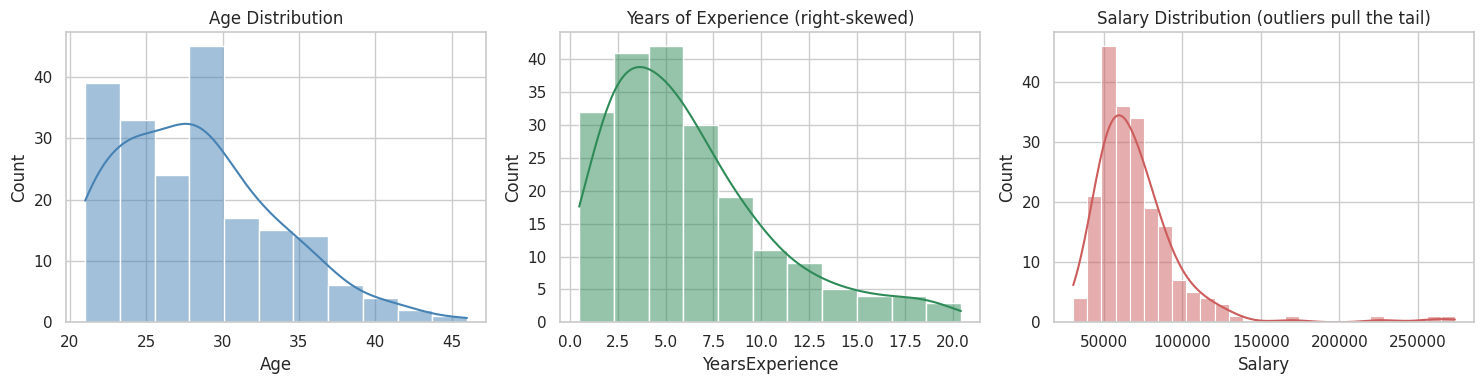

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['YearsExperience'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Years of Experience (right-skewed)')

sns.histplot(df['Salary'], kde=True, ax=axes[2], color='indianred')
axes[2].set_title('Salary Distribution (outliers pull the tail)')

plt.tight_layout()
plt.show()

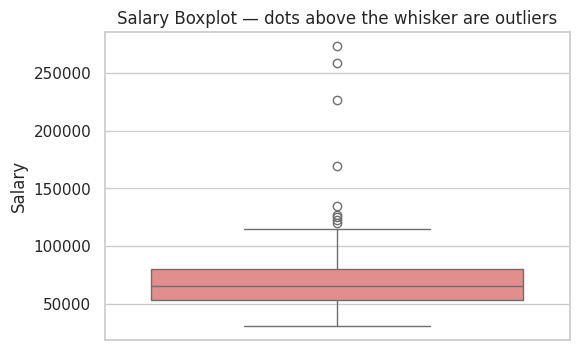

In [5]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Salary'], color='lightcoral')
plt.title('Salary Boxplot — dots above the whisker are outliers')
plt.show()

## 🔗 4. Bivariate Analysis: Relationships Between Features

Now we look for patterns **between** two variables — this is where EDA starts to hint at feature importance.


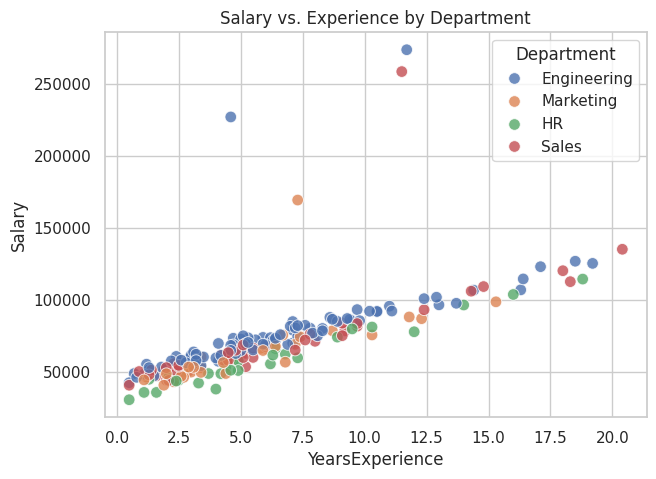

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='YearsExperience', y='Salary', hue='Department', s=70, alpha=0.8)
plt.title('Salary vs. Experience by Department')
plt.show()

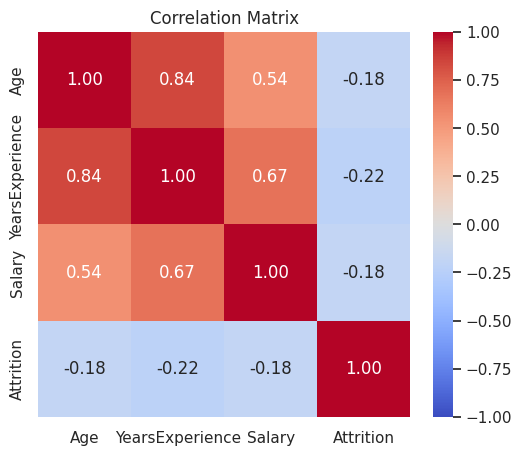

,Age,YearsExperience,Salary,Attrition
Age,1.000000,0.836173,0.540258,-0.182665
YearsExperience,0.836173,1.000000,0.674454,-0.218857
Salary,0.540258,0.674454,1.000000,-0.181248
Attrition,-0.182665,-0.218857,-0.181248,1.000000


In [7]:
numeric_cols = ['Age', 'YearsExperience', 'Salary', 'Attrition']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

corr

## 🏷 5. Categorical Analysis

Numeric summaries hide category-level stories. Let's break attrition down by department.


/tmp/ipykernel_526/3884521394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Department', ax=axes[0], palette='viridis',
/tmp/ipykernel_526/3884521394.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_rate.index, y=attrition_rate.values, ax=axes[1], palette='rocket')


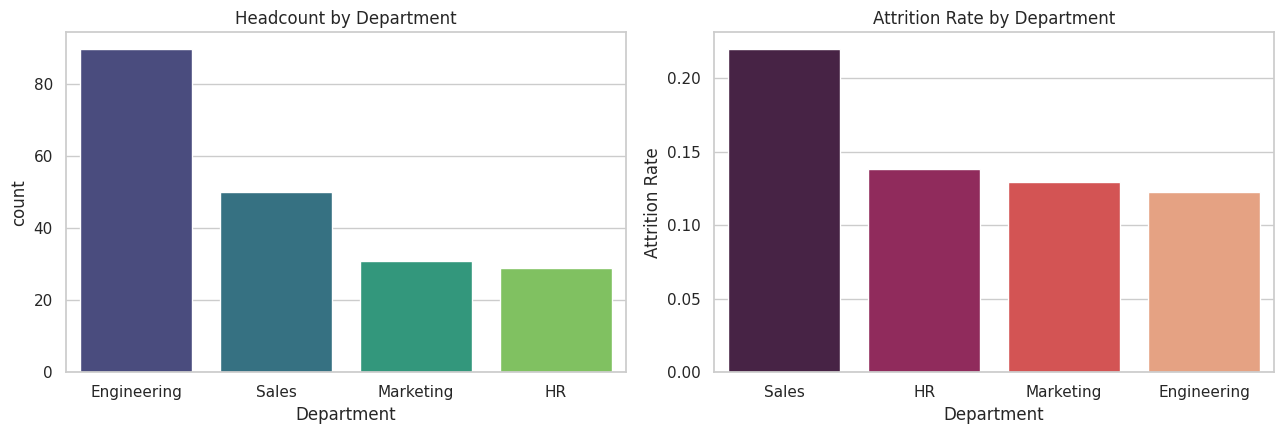

Department
Sales          0.220000
HR             0.137931
Marketing      0.129032
Engineering    0.122222
Name: Attrition, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x='Department', ax=axes[0], palette='viridis',
              order=df['Department'].value_counts().index)
axes[0].set_title('Headcount by Department')

attrition_rate = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False)
sns.barplot(x=attrition_rate.index, y=attrition_rate.values, ax=axes[1], palette='rocket')
axes[1].set_title('Attrition Rate by Department')
axes[1].set_ylabel('Attrition Rate')

plt.tight_layout()
plt.show()

attrition_rate

## 🚨 6. Outlier Detection with the IQR Method

A simple, robust rule: any point beyond **1.5 × IQR** from the quartiles is flagged as a potential outlier.

$$\text{Lower Bound} = Q_1 - 1.5 \times IQR \qquad \text{Upper Bound} = Q_3 + 1.5 \times IQR$$


In [9]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]

print(f"Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
print(f"Valid range: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"\nFound {len(outliers)} salary outlier(s):")
outliers[['Age', 'Department', 'YearsExperience', 'Salary']]

Q1=53350, Q3=79775, IQR=26425
Valid range: [13712, 119412]

Found 9 salary outlier(s):


,Age,Department,YearsExperience,Salary
34,30,Marketing,7.3,169176.229308
41,46,Sales,20.4,135000.000000
59,34,Engineering,18.5,126700.000000
61,33,Engineering,11.7,273548.809828
128,41,Engineering,19.2,125200.000000
141,27,Engineering,4.6,226877.981956
142,30,Sales,11.5,258386.148446
153,38,Sales,18.0,120100.000000
175,41,Engineering,17.1,122900.000000


## 🏁 Conclusion & Challenge

**Summary:**
In this module, we successfully:
1. Simulated a realistic HR dataset with numeric and categorical features.
2. Explored **univariate** distributions with histograms and boxplots.
3. Explored **bivariate** relationships with scatter plots and a correlation heatmap.
4. Broke down attrition by **categorical** groups (Department).
5. Detected outliers using the **IQR method**.

---

### 🧠 Challenge for You:
Add a `pairplot` (`sns.pairplot`) colored by `Attrition` to visualize all numeric relationships at once. Which feature seems to separate employees who left from those who stayed the most clearly?


In [10]:
# Your code here
